# Importing dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
# from xgboost import XGBClassifier
# from catboost import CatBoostClassifier

# Exploring Dataset

In [2]:
# Load the dataset
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Removing null values

In [5]:
df.drop(['customerID'], axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.dropna(inplace=True)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Encoding Data

In [6]:
# Encoding function
def object_to_int(dataframe_series):
    if dataframe_series.dtype == 'object':
        return LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

df_encoded = df.apply(lambda x: object_to_int(x))
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


# Data correlation

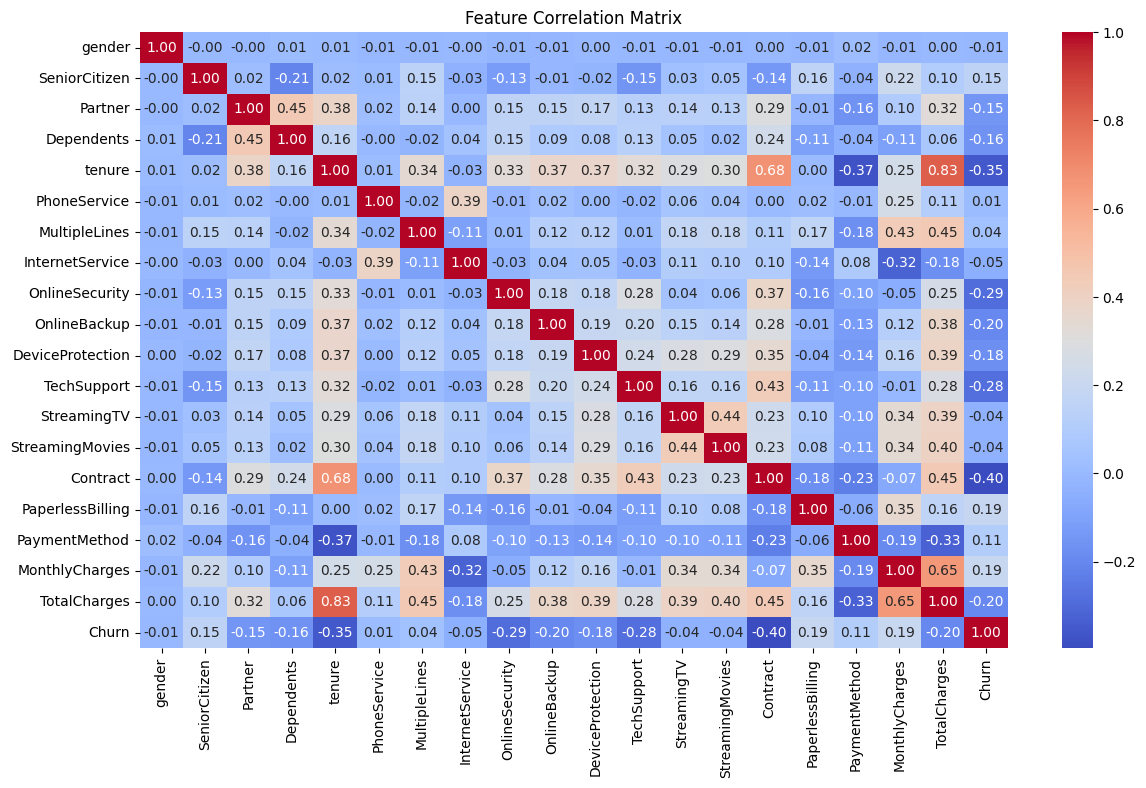

In [7]:
# Correlation Matrix to identify key drivers
plt.figure(figsize=(14, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

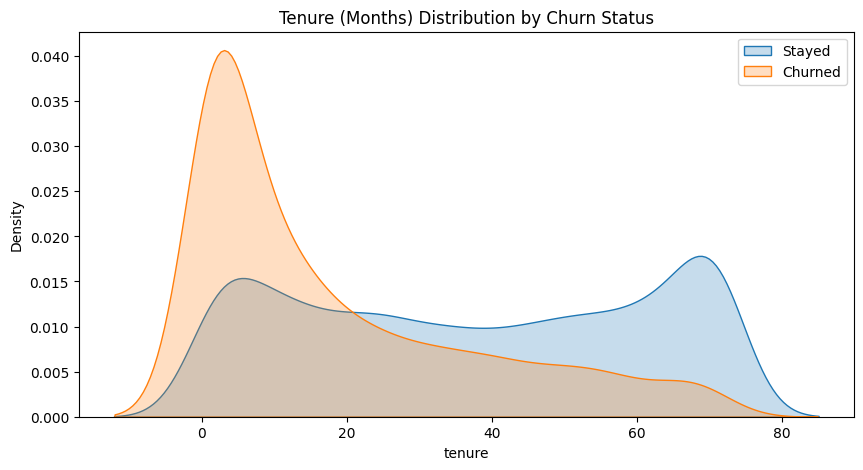

In [8]:
# Visualizing Tenure vs Churn
plt.figure(figsize=(10, 5))
sns.kdeplot(df_encoded[df_encoded['Churn'] == 0]['tenure'], label='Stayed', fill=True)
sns.kdeplot(df_encoded[df_encoded['Churn'] == 1]['tenure'], label='Churned', fill=True)
plt.title('Tenure (Months) Distribution by Churn Status')
plt.legend()
plt.show()

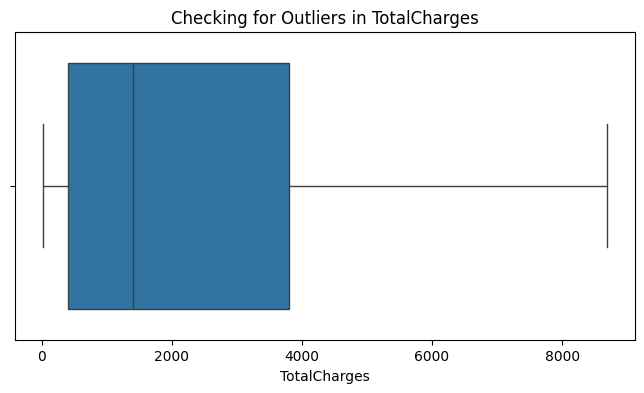

In [9]:
# 1. Visual Check (Box Plot)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['TotalCharges'])
plt.title('Checking for Outliers in TotalCharges')
plt.show()

In [10]:
# 2. Statistical Check (IQR Method)
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['TotalCharges'] < lower_bound) | (df['TotalCharges'] > upper_bound)]
print(f"Number of outliers detected: {len(outliers)}")

# 3. Pruning (Example: Capping outliers to the Upper Bound)
df['TotalCharges'] = np.where(df['TotalCharges'] > upper_bound, upper_bound, df['TotalCharges'])
df['TotalCharges'] = np.where(df['TotalCharges'] < lower_bound, lower_bound, df['TotalCharges'])

Number of outliers detected: 0


# Training Model

In [11]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features for SVM and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
def evaluate_model(model, X_train_data, y_train_data, X_test_data, name):
    # Now using y_train_data passed as an argument instead of global y_train
    model.fit(X_train_data, y_train_data)
    preds = model.predict(X_test_data)
    
    print(f"--- {name} Results ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

--- Logistic Regression Results ---
Accuracy: 0.7370

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



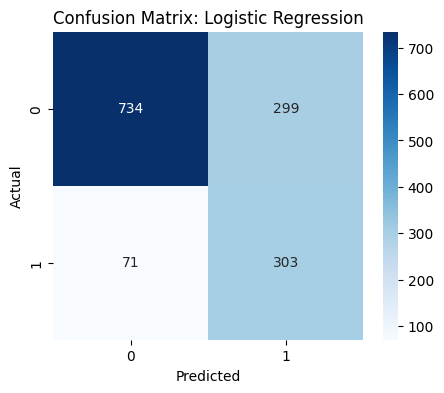

--- Random Forest Results ---
Accuracy: 0.7832

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



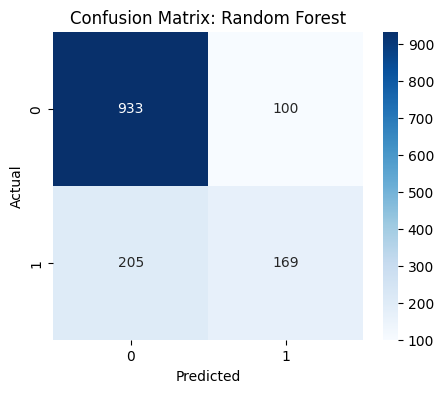

--- Decision Tree Results ---
Accuracy: 0.7264

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1033
           1       0.49      0.50      0.49       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



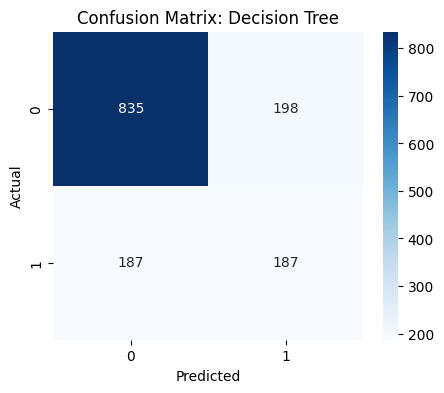

--- SVM Results ---
Accuracy: 0.7306

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.50      0.76      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



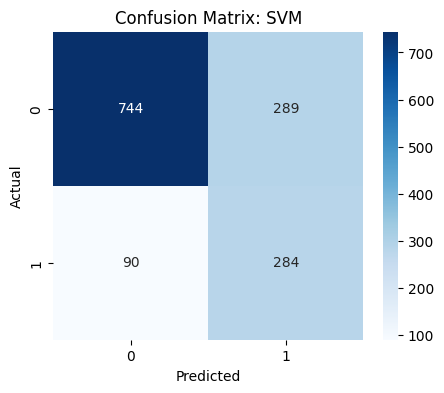

--- KNN Results ---
Accuracy: 0.7448

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1033
           1       0.52      0.49      0.51       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407



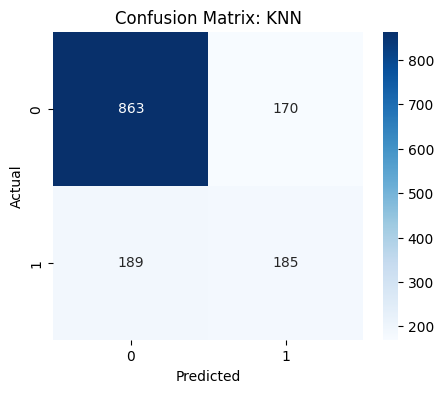

--- AdaBoostClassifier Results ---
Accuracy: 0.7875

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



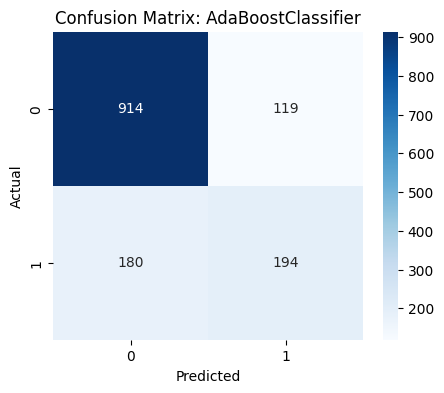

--- GradientBoostingClassifier Results ---
Accuracy: 0.7377

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.50      0.71      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407



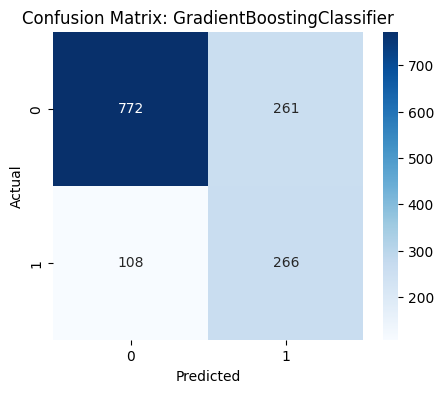

In [13]:
# 1. Logistic Regression  
evaluate_model(LogisticRegression(class_weight='balanced'), X_train_scaled, y_train, X_test_scaled, "Logistic Regression")

# 2. Random Forest  
evaluate_model(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42), X_train, y_train, X_test, "Random Forest")

# 3. Decision Tree 
evaluate_model(DecisionTreeClassifier(class_weight='balanced', random_state=42), X_train, y_train, X_test, "Decision Tree")

# 4. SVM 
evaluate_model(SVC(probability=True, class_weight='balanced'), X_train_scaled, y_train, X_test_scaled, "SVM")

# 5. KNN 
evaluate_model(KNeighborsClassifier(n_neighbors = 11), X_train_scaled, y_train, X_test_scaled, "KNN")

# 6. AdaBoostClassifier
evaluate_model(AdaBoostClassifier(), X_train_scaled, y_train, X_test_scaled, "AdaBoostClassifier")

# 7. GradientBoostingClassifier
evaluate_model(HistGradientBoostingClassifier(class_weight='balanced'), X_train_scaled, y_train, X_test_scaled, "GradientBoostingClassifier")


# Training with class balancing

In [14]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
sm = SMOTE(random_state=42)

# Resample for Scaled Models (LR, SVM)
X_train_res_scaled, y_train_res_scaled = sm.fit_resample(X_train_scaled, y_train)

# Resample for Tree Models (RF, DT)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

--- Logistic Regression Results ---
Accuracy: 0.7356

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



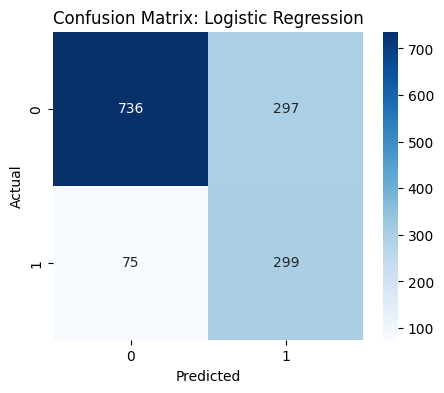

--- Random Forest Results ---
Accuracy: 0.7655

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1033
           1       0.56      0.57      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407



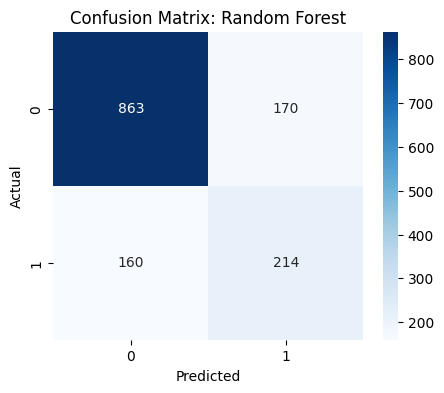

--- Decision Tree Results ---
Accuracy: 0.7193

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      1033
           1       0.47      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.65      1407
weighted avg       0.73      0.72      0.72      1407



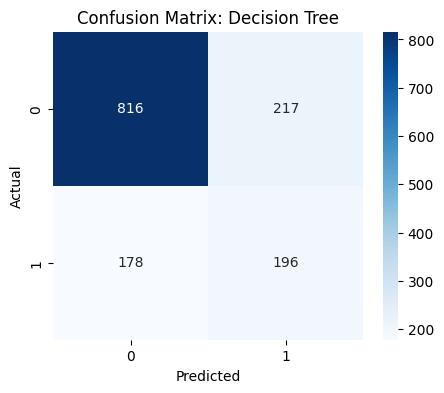

--- SVM Results ---
Accuracy: 0.7491

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



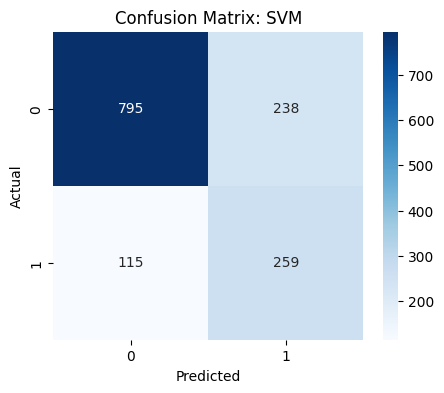

--- KNN Results ---
Accuracy: 0.6716

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.63      0.74      1033
           1       0.44      0.80      0.56       374

    accuracy                           0.67      1407
   macro avg       0.67      0.71      0.65      1407
weighted avg       0.77      0.67      0.69      1407



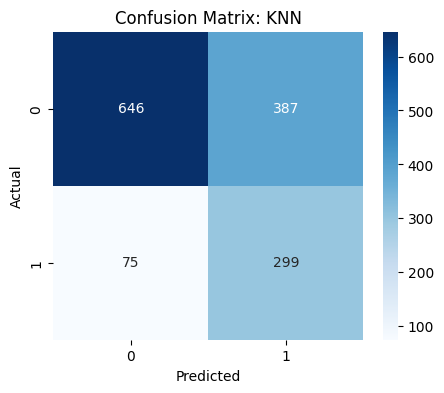

--- AdaBoostClassifier Results ---
Accuracy: 0.7285

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



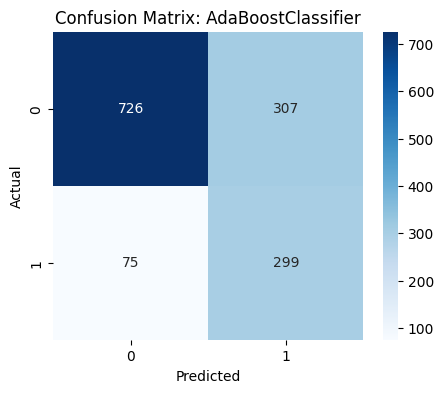

--- GradientBoostingClassifier Results ---
Accuracy: 0.7754

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1033
           1       0.57      0.61      0.59       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



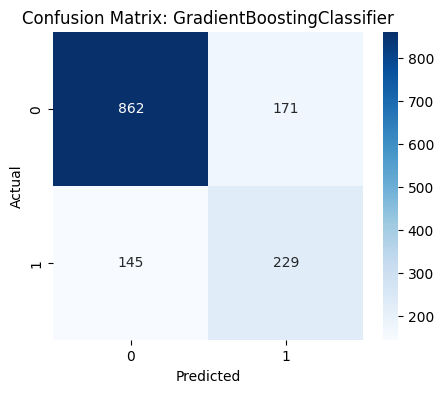

In [15]:
# --- Evaluate SMOTE Models ---

# 1. Logistic Regression  
evaluate_model(LogisticRegression(), X_train_res_scaled, y_train_res_scaled, X_test_scaled, "Logistic Regression")

# 2. Random Forest  
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), X_train_res, y_train_res, X_test, "Random Forest")

# 3. Decision Tree  
evaluate_model(DecisionTreeClassifier(class_weight='balanced', random_state=42), X_train_res, y_train_res, X_test, "Decision Tree")

# 4. SVM  
evaluate_model(SVC(probability=True), X_train_res_scaled, y_train_res_scaled, X_test_scaled, "SVM")

# 5. KNN 
evaluate_model(KNeighborsClassifier(n_neighbors = 11), X_train_res_scaled, y_train_res_scaled, X_test_scaled, "KNN")

# 6. AdaBoostClassifier
evaluate_model(AdaBoostClassifier(), X_train_res_scaled, y_train_res_scaled, X_test_scaled, "AdaBoostClassifier")

# 7. GradientBoostingClassifier
evaluate_model(HistGradientBoostingClassifier(class_weight='balanced'), X_train_res_scaled, y_train_res_scaled, X_test_scaled, "GradientBoostingClassifier")

# Feature selection

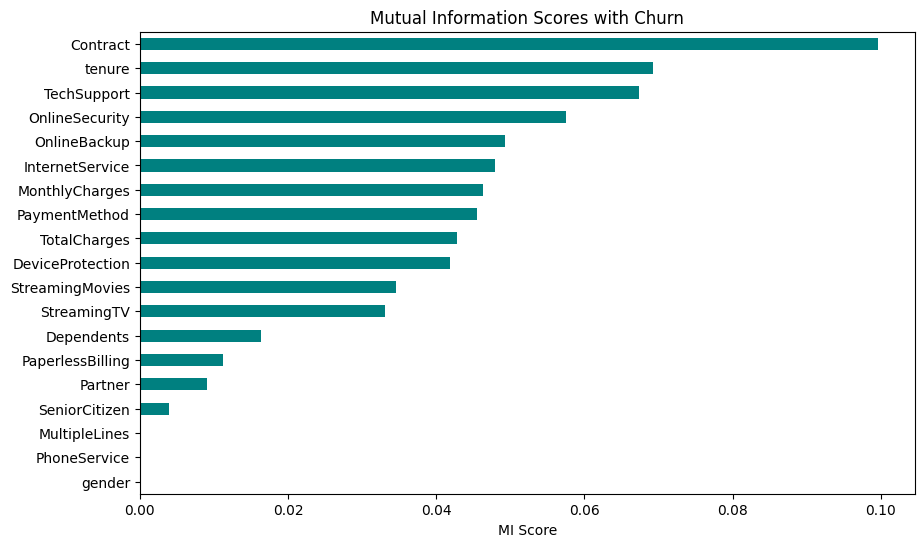

In [16]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import pandas as pd

# Calculate MI scores
# X and y should be your encoded training data
importances = mutual_info_classif(X, y)
feature_importances = pd.Series(importances, index=X.columns)

# Visualize the scores
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Mutual Information Scores with Churn')
plt.xlabel('MI Score')
plt.show()

In [17]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Initialize the base model
# We use LogisticRegression here, but you can use RandomForestClassifier too
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Initialize RFE to select the top 10 features
rfe = RFE(estimator=model, n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

# Summarize the selection
ranking = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Rank': rfe.ranking_
})

# Display features sorted by rank (Rank 1 = Top Features)
print(ranking.sort_values(by='Rank'))

             Feature  Selected  Rank
18      TotalCharges      True     1
1      SeniorCitizen      True     1
15  PaperlessBilling      True     1
14          Contract      True     1
4             tenure      True     1
5       PhoneService      True     1
11       TechSupport      True     1
7    InternetService      True     1
8     OnlineSecurity      True     1
17    MonthlyCharges      True     1
9       OnlineBackup     False     2
3         Dependents     False     3
10  DeviceProtection     False     4
16     PaymentMethod     False     5
6      MultipleLines     False     6
2            Partner     False     7
12       StreamingTV     False     8
13   StreamingMovies     False     9
0             gender     False    10


In [18]:
# List of top 10 features selected by RFE
selected_features = [
    'TotalCharges', 'SeniorCitizen', 'PaperlessBilling', 'Contract', 
    'tenure', 'PhoneService', 'TechSupport', 'InternetService', 
    'OnlineSecurity', 'MonthlyCharges'
]

# Filter the training and testing sets
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]


In [19]:
scaler_selected = StandardScaler()

# Scale the selected features
X_train_sel_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_sel_scaled = scaler_selected.transform(X_test_selected)

# Training model with selected features

--- Logistic Regression Results ---
Accuracy: 0.7242

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407



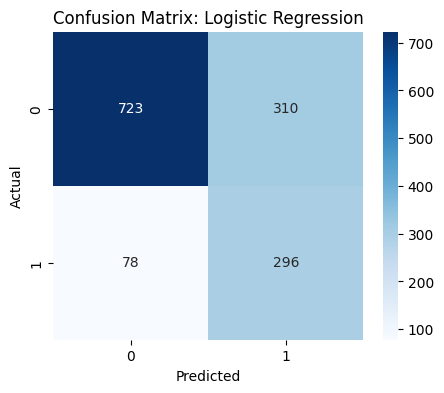

--- Random Forest Results ---
Accuracy: 0.7818

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



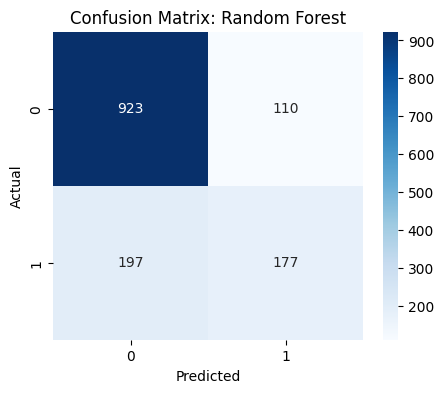

--- Decision Tree Results ---
Accuracy: 0.7427

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1033
           1       0.52      0.51      0.51       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407



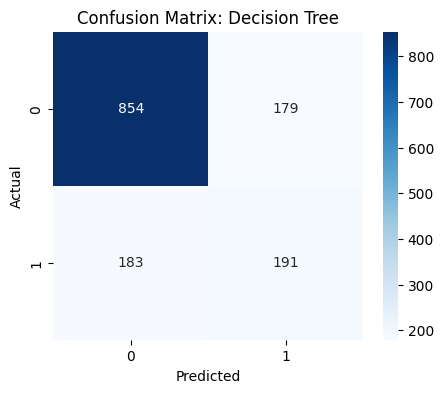

--- SVM Results ---
Accuracy: 0.7413

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



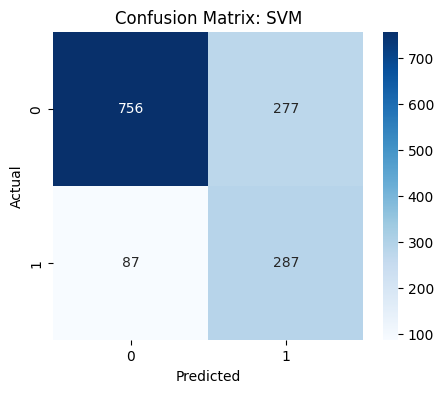

--- KNN Results ---
Accuracy: 0.7825

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



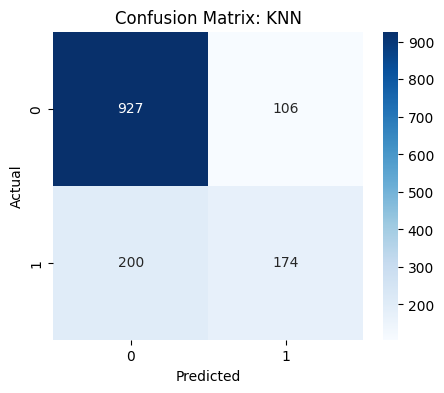

--- AdaBoostClassifier Results ---
Accuracy: 0.7868

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



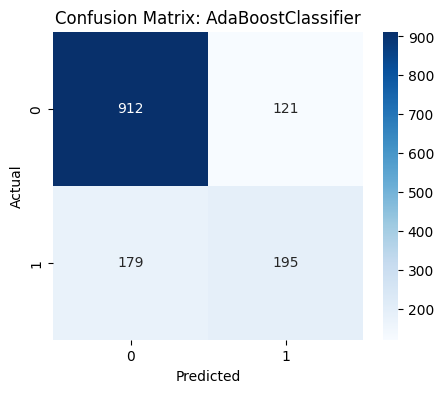

--- GradientBoostingClassifier Results ---
Accuracy: 0.7313

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80      1033
           1       0.50      0.73      0.59       374

    accuracy                           0.73      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.73      0.74      1407



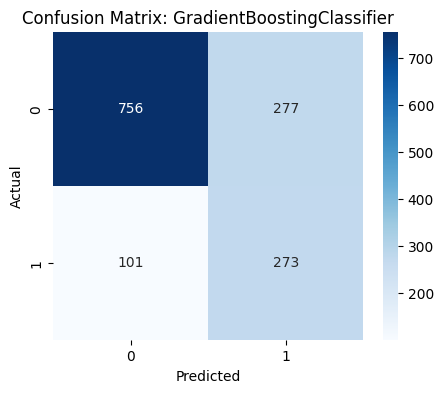

In [20]:
# 1. Logistic Regression  
evaluate_model(
    LogisticRegression(class_weight='balanced'), 
    X_train_sel_scaled, y_train, X_test_sel_scaled, 
    "Logistic Regression"
)

# 2. Random Forest  
evaluate_model(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42), 
    X_train_selected, y_train, X_test_selected, 
    "Random Forest"
)

# 3. Decision Tree  
evaluate_model(
    DecisionTreeClassifier(class_weight='balanced', random_state=42), 
    X_train_selected, y_train, X_test_selected, 
    "Decision Tree"
)

# 4. SVM
evaluate_model(
    SVC(probability=True, class_weight='balanced'), 
    X_train_sel_scaled, y_train, X_test_sel_scaled, 
    "SVM"
)

# 5. KNN 
evaluate_model(KNeighborsClassifier(n_neighbors = 11), X_train_sel_scaled, y_train, X_test_sel_scaled, "KNN")

# 6. AdaBoostClassifier
evaluate_model(AdaBoostClassifier(), X_train_sel_scaled, y_train, X_test_sel_scaled, "AdaBoostClassifier")

# 7. GradientBoostingClassifier
evaluate_model(HistGradientBoostingClassifier(class_weight='balanced'), X_train_sel_scaled, y_train, X_test_sel_scaled,"GradientBoostingClassifier")
